# Projeto de previsão de sobreviventes do Titanic

O projeto utiliza-se da base de dados do [Kaggle](https://www.kaggle.com/competitions/titanic/overview) e visa criar um modelo preditivo que, a partir da característica fornecida das pessoas, deverá prever se a mesma iria sobreviver ou não ao acidente envolvendo o navio Titanic.

A base de dados contém dos seguintes componentes:

- `PassangerID` - Coluna do tipo *int* que indica a posição no index;
- `Survived` - coluna do tipo *int*, é uma coluna dummy, ou seja, classificado em 2 categorias: 1 para indicar que sobreviveu e 0 para indicar que não sobreviveu;
- `Pclass` - coluna do tipo *int*, que indica a classe da passagem comprada, podendo ser categorizada em: 1 para 1º classe (mais cara), 2 para 2º classe e 3 para a 3º classe (mais barata);
- `Name` - coluna do tipo *String* que identifica o nome do passageiro;
- `Sex` - coluna do tipo *String* que identifica o sexo atribuído ao nascimento;
- `Age` - coluna do tipo *float* que identifica a idade;
- `SibSp` - coluna do tipo *int*, que indica a quantidade de cônjuge e/ou irmãos presentes no navio;
- `Parch` - coluna do tipo *int*, que indica a quantidade de pais e/ou filhos presentes no navio;
- `Ticket` - coluna do tipo *String* que indica o número da passagem comprada;
- `Fare` - coluna do tipo *float* que indica o valor pago pela passagem comprada;
- `Cabin` - coluna do tipo *String* que indica o número da cabine onde o passageiro ficou alocado;
- `Embarked` coluna do tipo *String*, que indica onde o passageiro embarcou, podendo ser categorizada em: C para Cherbourg, Q para Queenstown e S para Southampton.

Importei as bibliotecas necessárias que utilizei para a execução do projeto:

Pandas para limpeza e manipulação de dados;\
Numpy para cálculos;\
Matplotlib para criar figuras de visualização de gráficos;\
Seaborn para criar gráficos;\
Plotly para criar gráficos interativos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

\
A base de dados está dividida em dois arquivos, o **train.csv** para treinamento do modelo preditivo e o **test.csv** para teste da precisão do modelo. Criei um DataFrame para cada, visando a separação e deixando claro o objetivo de cada um.

In [2]:
df_train = pd.read_csv('data/train.csv')

In [3]:
df_test = pd.read_csv('data/test.csv')

\
Utilizei os métodos `head()` e `info()` do *Pandas* para comparar se os dois DataFrames possuem as mesma colunas e as mesmas tipagens de dados.

In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


\
Utilizei o gráfico de `mapa de calor` do *Seaborn* e o método `isnull()` do *Pandas* para verificar se existes valores nulos em ambos DataFrames, apresentando cores distintas caso haja valores nulos.

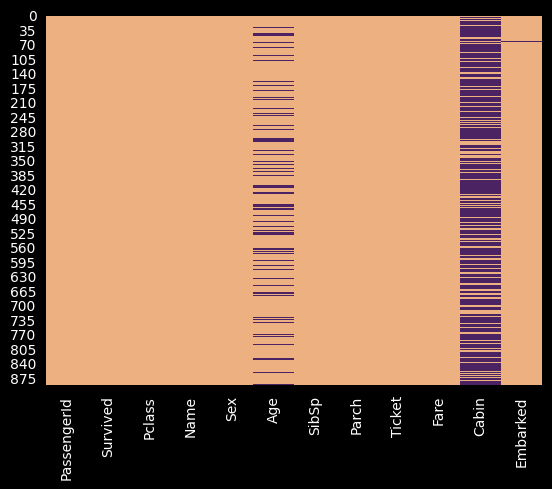

In [8]:
sns.heatmap(df_train.isnull(), cbar=False, cmap='flare')
plt.show()

<Axes: >

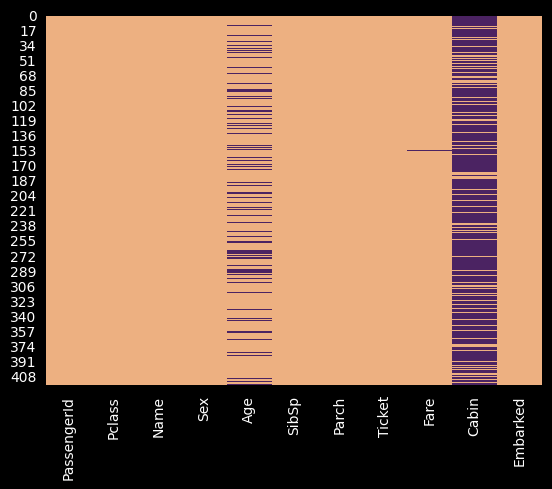

In [9]:
sns.heatmap(df_test.isnull(), cbar=False, cmap='flare')

\
Ambos DataFrames possuem diversos valores nulos nas colunas de idade e cabine, a única divergência é que o de treinamento possui um valor nulo de embarque e o de teste possui um valor nulo de tarifa.
\
\
Referente aos valores nulos de idade, o ideal é preencher com a média de idade. Para extrair tal informação fiz um gráfico interativo de `box` do *Plotly* para saber a média por classe.

In [10]:
age_per_class = px.box(data_frame=df_train, x='Pclass', y='Age', color='Pclass',
             labels={'Pclass': 'Classe', 'Age': 'idade'})
age_per_class.show()

\
Com a idade média por classe identificada, prossegui para criar uma função que troca as idades `null` para a idade média, conforme a classe da passagem.

In [11]:
def change_null_ages(columns):
    age = columns.iloc[0]
    passenger_class = columns.iloc[1]

    if np.isnan(age):
        if passenger_class == 1:
            return 37
        elif passenger_class == 2:
            return 29
        else:
            return 24

    else:
        return age

\
Agora foi só subscrever a coluna `Age`, aplicando a função que preenche as idades nulas pela idade média, a partir do próprio DataFrame, enviando como paramêtro as colunas de idade e classe.

In [12]:
df_train['Age'] = df_train[['Age', 'Pclass']].apply(change_null_ages, axis=1)

Acessei novamente o `mapa de calor` para verificar se teria algum resquício de registro nulo

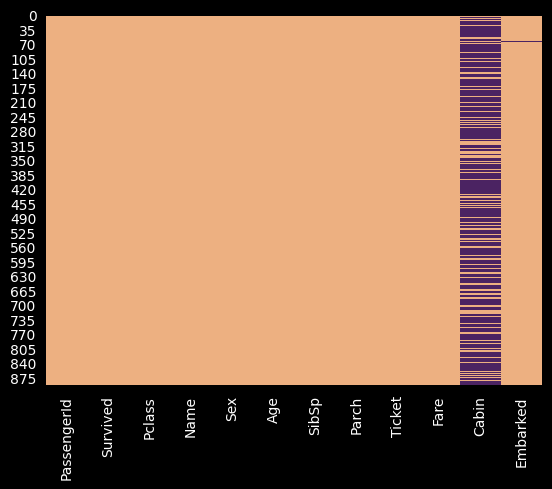

In [13]:
sns.heatmap(df_train.isnull(), cbar=False, cmap='flare')
plt.show()

In [14]:
df_test['Age'] = df_test[['Age', 'Pclass']].apply(change_null_ages, axis=1)

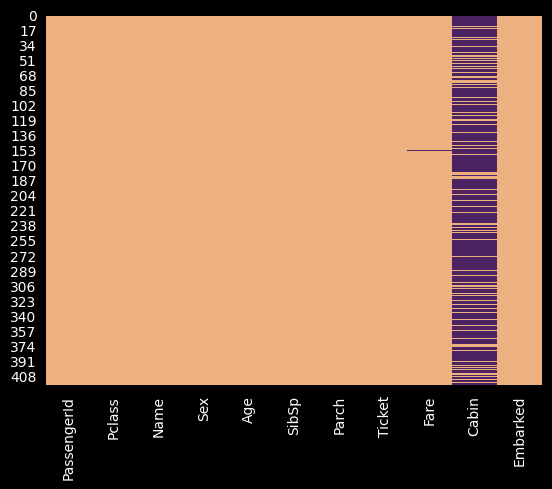

In [15]:
sns.heatmap(df_test.isnull(), cbar=False, cmap='flare')
plt.show()

Já referente aos dados nulos da coluna `Cabin`, por não ter peso na predição de sobrevivência e por apresentar na sua grande maioria dados faltantes, optei por retirar a coluna. Também optei por retirar as colunas `PassengerId`, pelo fato do DataFrame ter o seu próprio index e `Ticket` por não ter um padrão facilmente identificável.

In [16]:
df_train.drop(['Cabin','PassengerId', 'Ticket'], axis=1, inplace=True)

In [17]:
df_test.drop(['Cabin','PassengerId', 'Ticket'], axis=1, inplace=True)

In [18]:
df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [19]:
df_test.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,S
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,Q
3,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,S


Para ficar mais fácil do modelo de predição entender e interpretar as informações, alterei a coluna `Sex`, visto que os dados estavam divididos entre **male** e **female**, e os transformei em **0** e **1**, 0 sendo masculino e 1 sendo feminino.

In [20]:
sex_dict = {
    'male': 0,
    'female': 1
}

df_train = df_train.replace(sex_dict)

df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,S


In [21]:
df_test = df_test.replace(sex_dict)
df_test.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,"Kelly, Mr. James",0,34.5,0,0,7.8292,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.0000,S
2,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,9.6875,Q
3,3,"Wirz, Mr. Albert",0,27.0,0,0,8.6625,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,12.2875,S


Para a coluna de `Embarked` segui o mesmo princípio da coluna `Sex`, porém como se tratava de 3 classificações, optei por adicionar três colunas dummies. Os dados ficaram separados entre `Embarked_C`, `Embarked_Q` e `Embarked_S`.

In [22]:
embark = pd.get_dummies(df_train['Embarked'], prefix='Embarked_')
embark

,Embarked__C,Embarked__Q,Embarked__S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
886,False,False,True
887,False,False,True
888,False,False,True
889,True,False,False


Transformei os valores de `True` e `False` para **1** e **0**, respectivamente.

In [23]:
embark_dict = {
    False: 0,
    True: 1
}

embark = embark.replace(embark_dict)
embark

,Embarked__C,Embarked__Q,Embarked__S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
886,0,0,1
887,0,0,1
888,0,0,1
889,1,0,0


Com o método `concat()` do *Pandas*, concatenei os dois DataFrames, df_train e embark, para virar apenas um.

In [24]:
df_train = pd.concat([df_train, embark], axis=1)
df_train

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Embarked__C,Embarked__Q,Embarked__S
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,S,0,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C,1,0,0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,S,0,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,S,0,0,1
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,S,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,13.0000,S,0,0,1
887,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,30.0000,S,0,0,1
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,24.0,1,2,23.4500,S,0,0,1
889,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,30.0000,C,1,0,0


Com as novas colunas dummies de `Embarked`, essa coluna se tornou desnecessária, por isso optei por deletar ela.

In [25]:
df_train.drop('Embarked', axis=1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked__C,Embarked__Q,Embarked__S
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,0,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,1,0,0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,0,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,0,0,1
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,13.0000,0,0,1
887,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,30.0000,0,0,1
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,24.0,1,2,23.4500,0,0,1
889,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,30.0000,1,0,0


Aplicando a mesma linha de raciocínio do `Embarked`, porém para o DataFrame de teste.

In [26]:
embark_test = pd.get_dummies(df_test['Embarked'], prefix='Embarked_')
embark_test

,Embarked__C,Embarked__Q,Embarked__S
0,False,True,False
1,False,False,True
2,False,True,False
3,False,False,True
4,False,False,True
...,...,...,...
413,False,False,True
414,True,False,False
415,False,False,True
416,False,False,True


In [27]:
embark_test = embark_test.replace(embark_dict)
embark_test

,Embarked__C,Embarked__Q,Embarked__S
0,0,1,0
1,0,0,1
2,0,1,0
3,0,0,1
4,0,0,1
...,...,...,...
413,0,0,1
414,1,0,0
415,0,0,1
416,0,0,1


In [28]:
df_test = pd.concat([df_test, embark_test], axis=1)
df_test

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Embarked__C,Embarked__Q,Embarked__S
0,3,"Kelly, Mr. James",0,34.5,0,0,7.8292,Q,0,1,0
1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.0000,S,0,0,1
2,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,9.6875,Q,0,1,0
3,3,"Wirz, Mr. Albert",0,27.0,0,0,8.6625,S,0,0,1
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,12.2875,S,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",0,24.0,0,0,8.0500,S,0,0,1
414,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,108.9000,C,1,0,0
415,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,7.2500,S,0,0,1
416,3,"Ware, Mr. Frederick",0,24.0,0,0,8.0500,S,0,0,1


In [29]:
df_test.drop('Embarked', axis=1)

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked__C,Embarked__Q,Embarked__S
0,3,"Kelly, Mr. James",0,34.5,0,0,7.8292,0,1,0
1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.0000,0,0,1
2,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,9.6875,0,1,0
3,3,"Wirz, Mr. Albert",0,27.0,0,0,8.6625,0,0,1
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,12.2875,0,0,1
...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",0,24.0,0,0,8.0500,0,0,1
414,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,108.9000,1,0,0
415,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,7.2500,0,0,1
416,3,"Ware, Mr. Frederick",0,24.0,0,0,8.0500,0,0,1
